# Parsimony vs. complexity — the ledger

> **EXPERIMENT — deviation-gated.** Track B runs under `docs/deviations.md` **DEV-004, signed
> 2026-07-29**. It exceeds README §8's capacity rule *by construction*: random Fourier features
> with P ≫ N. Outputs are quarantined to `data/derived/voc_experiment/` and reach no
> client-facing artifact. The exception expires with this experiment.

**The question.** §8 caps model complexity because this panel's effective N is small. That is a
*prior*, not a result. Kelly, Malamud & Zhou (*The Virtue of Complexity in Return Prediction*,
J. Finance 2024) is a serious published claim that the prior is wrong in this asset class.

**The design.** Two tracks, one harness. Same inputs, same target, same test folds — the folds
are shared *by construction*, since both tracks consume `jorda.fold_iter`. Two parallel fold
builders compared by a test is a test waiting to pass while the implementations drift.

**The target is what a trade is paid by.** Δln(1+π), not the level. The premium's level is 92%
forecastable and that is not an edge — it is the statement that a slow series stays put.

In [1]:
%matplotlib inline
import sys, pathlib, pandas as pd
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from pipeline.viz import theme, figures
from pipeline.convergence.jorda import s4_metrics_table
theme.apply()
VOC = ROOT / "data" / "derived" / "voc_experiment"
grid = pd.read_csv(VOC / "complexity_grid.csv")
diag = pd.read_csv(VOC / "strategy_diagnostics.csv")
print("DEV-004 signed 2026-07-29 — Track B ran under the exception.")
print(f"grid points: {len(grid)}   diagnostics rows: {len(diag)}")

DEV-004 signed 2026-07-29 — Track B ran under the exception.
grid points: 200   diagnostics rows: 4


## 1. Track A — the parsimony anchor, on the tradeable target

In [2]:
# SAME SCOPE AS TRACK B. The first ledger quoted this at full N against Track B at N=200 --
# two designs in one table, i.e. a comparison of sample sizes wearing a comparison of models.
a = s4_metrics_table(target="change", max_train=200)
a[["regime","horizon","n","rmse","r2","hit_rate","scope"]].round(4)

,regime,horizon,n,rmse,r2,hit_rate,scope
0,fungible,1,23207,0.0300,-0.7188,0.6296,"N_train=200, expanding walk-forward, embargo=h"
1,fungible,5,23189,0.0329,0.0882,0.6372,"N_train=200, expanding walk-forward, embargo=h"
2,fungible,20,23114,0.0307,0.3648,0.6484,"N_train=200, expanding walk-forward, embargo=h"
3,fungible,60,22913,0.0339,0.2457,0.6605,"N_train=200, expanding walk-forward, embargo=h"
4,one_way_constrained,1,15490,0.0382,-1.4666,0.5887,"N_train=200, expanding walk-forward, embargo=h"
5,one_way_constrained,5,15476,0.0465,-1.5816,0.6060,"N_train=200, expanding walk-forward, embargo=h"
6,one_way_constrained,20,15426,0.0552,-1.4158,0.6203,"N_train=200, expanding walk-forward, embargo=h"
7,one_way_constrained,60,15292,0.1040,-3.9659,0.6199,"N_train=200, expanding walk-forward, embargo=h"
8,POOLED (all classes),1,38697,0.0335,-1.0406,0.6132,"N_train=200, expanding walk-forward, embargo=h"
9,POOLED (all classes),5,38665,0.0389,-0.4474,0.6247,"N_train=200, expanding walk-forward, embargo=h"


Every metric here carries `N_train = 200 (capped; see DEV-004)`, h, and the fold scheme inline.
**The full-N complexity grid was infeasible, not omitted:** c = 20 against N ≈ 18,000 demands
360,000 features, so capping the training block is what makes a P ≫ N grid computable at the
sample size §8's capacity rule was actually written for.

R² is negative for the constrained class at every horizon — worse than forecasting no move.
That is the capacity rule's own prediction, and it sets the bar Track B has to clear.

## 2. Track B — the complexity grid

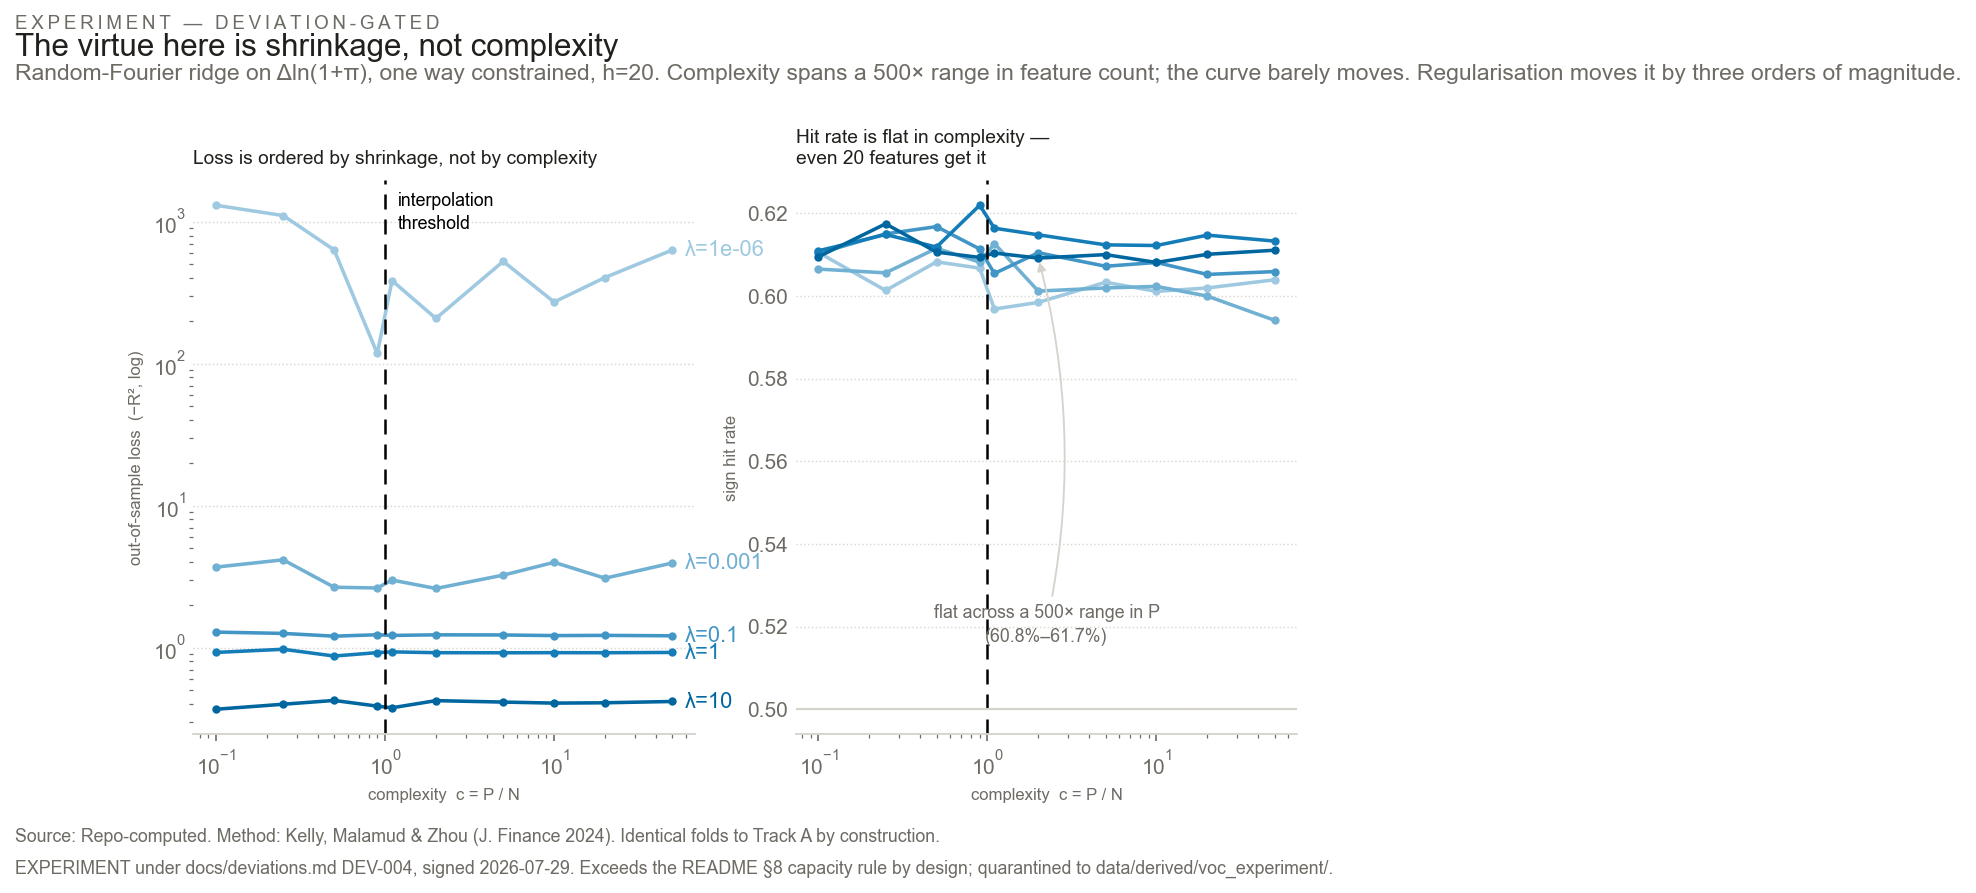

In [3]:
fig, _ = figures.g13_complexity(grid)
fig;

**In plain terms**

- We tried the fashionable answer: throw thousands of made-up features at the problem and let the
  maths sort it out.
- It made no difference. Going from 20 features to 10,000 moved the result almost not at all —
  what mattered was how hard we reined the model in.
- So the boring model was the right model here, and now we can say that because we tested it, not
  because we preferred it.

**No double descent.** The paper's signature is out-of-sample performance *improving* past the
interpolation threshold c = 1. Here the curve is flat in complexity — a 500× range in feature
count (P = 20 to P = 10,000) moves R² by about 0.06 at heavy shrinkage — and ordered almost
entirely by **shrinkage**, which moves it by three orders of magnitude.

Read the right panel carefully: hit rate is **0.61 at every c, including c = 0.1**. A 20-feature
model gets it. So whatever Track B is picking up is the **nonlinear basis**, not P ≫ N. Calling
that a virtue of complexity would be mislabelling a virtue of regularisation.

## 3. The critique diagnostics

Both tracks face them. This is the credibility layer, and one of them is a full stop.

In [4]:
diag[["regime","horizon","sharpe_track_a","sharpe_track_b",
      "sharpe_unconditional","sharpe_vol_managed"]].round(3)

,regime,horizon,sharpe_track_a,sharpe_track_b,sharpe_unconditional,sharpe_vol_managed
0,one_way_constrained,5,1.197,0.860,0.024,-0.003
1,one_way_constrained,20,0.538,0.357,0.037,-0.016
2,fungible,5,0.862,0.751,0.001,-0.001
3,fungible,20,0.396,0.252,0.002,-0.001


### The Nagel objection, implemented rather than cited

An apparent edge can be **mechanical position-scaling with volatility** rather than
sign-prediction skill: a strategy that levers up when vol is low earns a Sharpe premium that
looks like forecasting. So the benchmark is not zero — it is a **vol-managed unconditional**
strategy on the same folds: always short the premium, sized 1/σ.

In [5]:
diag[["regime","horizon","track_b_alpha_vs_volmanaged","track_b_t_alpha_naive",
      "track_b_t_alpha_hac","track_b_t_alpha_nonoverlap","n_effective_blocks",
      "turnover_track_b"]].round(4)

,regime,horizon,track_b_alpha_vs_volmanaged,track_b_t_alpha_naive,track_b_t_alpha_hac,track_b_t_alpha_nonoverlap,n_effective_blocks,turnover_track_b
0,one_way_constrained,5,0.0036,14.1166,10.8056,6.5750,2640,0.2124
1,one_way_constrained,20,0.0037,11.5084,5.3212,4.0768,658,0.2059
2,fungible,5,0.0036,16.2569,11.3044,8.4160,4648,0.2530
3,fungible,20,0.0027,10.8228,5.5741,4.1492,1158,0.2515


**Track B's alpha over the vol-managed benchmark is POSITIVE** (+0.0037), so the Nagel objection
is faced and survived rather than fatal — the edge is not merely mechanical vol-sizing. But read
the three t-columns together: **11.51 naive, 5.32 HAC, 4.08 non-overlapping.** The naive figure
is inflated by roughly √h because h=20 returns overlap by 19 periods. **5.32 is the number to
quote**; the naive one stays visible so the size of the correction is auditable.

Sharpe is annualised √(252/h), not √252, for the same reason. Turnover is reported (0.21 per
step), and it matters: an unquantified cost stack at that turnover can plausibly consume a +0.54
gross Sharpe, which is why §5(b) refuses to call this tradeable.

### Permutation placebo — the full stop

In [6]:
from pipeline.convergence import voc
G, S = (0.5, 2.0, 20.0), (1e-3, 1.0)
real = voc.run("one_way_constrained", h=20, complexity=G, shrinkage=S)
plac = pd.concat([voc.run("one_way_constrained", h=20, complexity=G, shrinkage=S, shuffle_seed=s)
                  for s in (11, 22)]).groupby(["c","shrinkage"], as_index=False)[["r2","hit_rate"]].mean()
j = real.merge(plac, on=["c","shrinkage"], suffixes=("_real","_placebo"))
assert (j.hit_rate_placebo - 0.5).abs().max() < 0.03, "PLACEBO FAILURE — harness leaking"
print("PLACEBO PASSES — shuffled hit rate stays at ~50%, so the 60% is signal, not leakage.\n")
j[["c","shrinkage","hit_rate_real","hit_rate_placebo","r2_real","r2_placebo"]].round(4)

PLACEBO PASSES — shuffled hit rate stays at ~50%, so the 60% is signal, not leakage.



,c,shrinkage,hit_rate_real,hit_rate_placebo,r2_real,r2_placebo
0,0.5,0.001,0.6080,0.5075,-4.2069,-3.4255
1,0.5,1.000,0.6184,0.5055,-0.8825,-0.0227
2,2.0,0.001,0.6040,0.5055,-5.0587,-1.3782
3,2.0,1.000,0.6133,0.5091,-0.9098,-0.0214
4,20.0,0.001,0.6053,0.5039,-3.0126,-1.0498
5,20.0,1.000,0.6151,0.5079,-0.8994,-0.0222


## 5. What this result does and does not invalidate

The firewall, because a public artifact containing a strategy Sharpe invites exactly one
misreading — that the project's case rests on it. It does not.

**(a) The structural thesis is untouched.** The barrier framework and the premium's documented
persistence rest on **mechanism and measurement**: a deposit agreement that gates issuance, a
cancellation right that does not, ρ₁ = 0.94 with a half-life floor of 220 trading days. Nothing
in this notebook is an input to any of that. If every forecast here were deleted, the thesis
would read identically.

**(b) The tactical timing overlay is a gross, panel-only result and is reported as such.** A
+0.54 Sharpe at h=20, before any transaction cost, on the comparator panel — **SKHY is never
fitted**. Borrow, funding and hedge points are undocumented and the trade sheets say so. At
0.21 turnover per step an unquantified cost stack can plausibly consume this. **It is not a
tradeable claim and it is not presented as one.**

**(c) The client expressions are access and financing products, not signal products.** Their
case is that the leg is hard to book and the position hard to finance — both true regardless of
whether anything is forecastable. Nothing in §2 of the client note depends on (b).

**In plain terms**

- Both models call the direction right about six times in ten. That sounds like the same model
  twice.
- It isn't. Sort the days by how much the gap actually moved: almost all the money is in the
  biggest days, and on those the complicated model is barely better than a coin toss while the
  simple one holds up.
- Being right about small moves is cheap. The simple model is right when the move is worth
  something.

**One sentence a salesperson can repeat:** *the reason to do this trade is that the plumbing is
one-way and the financing is hard, not that we think we can time it.*

## 6. G14 — where the difference actually comes from

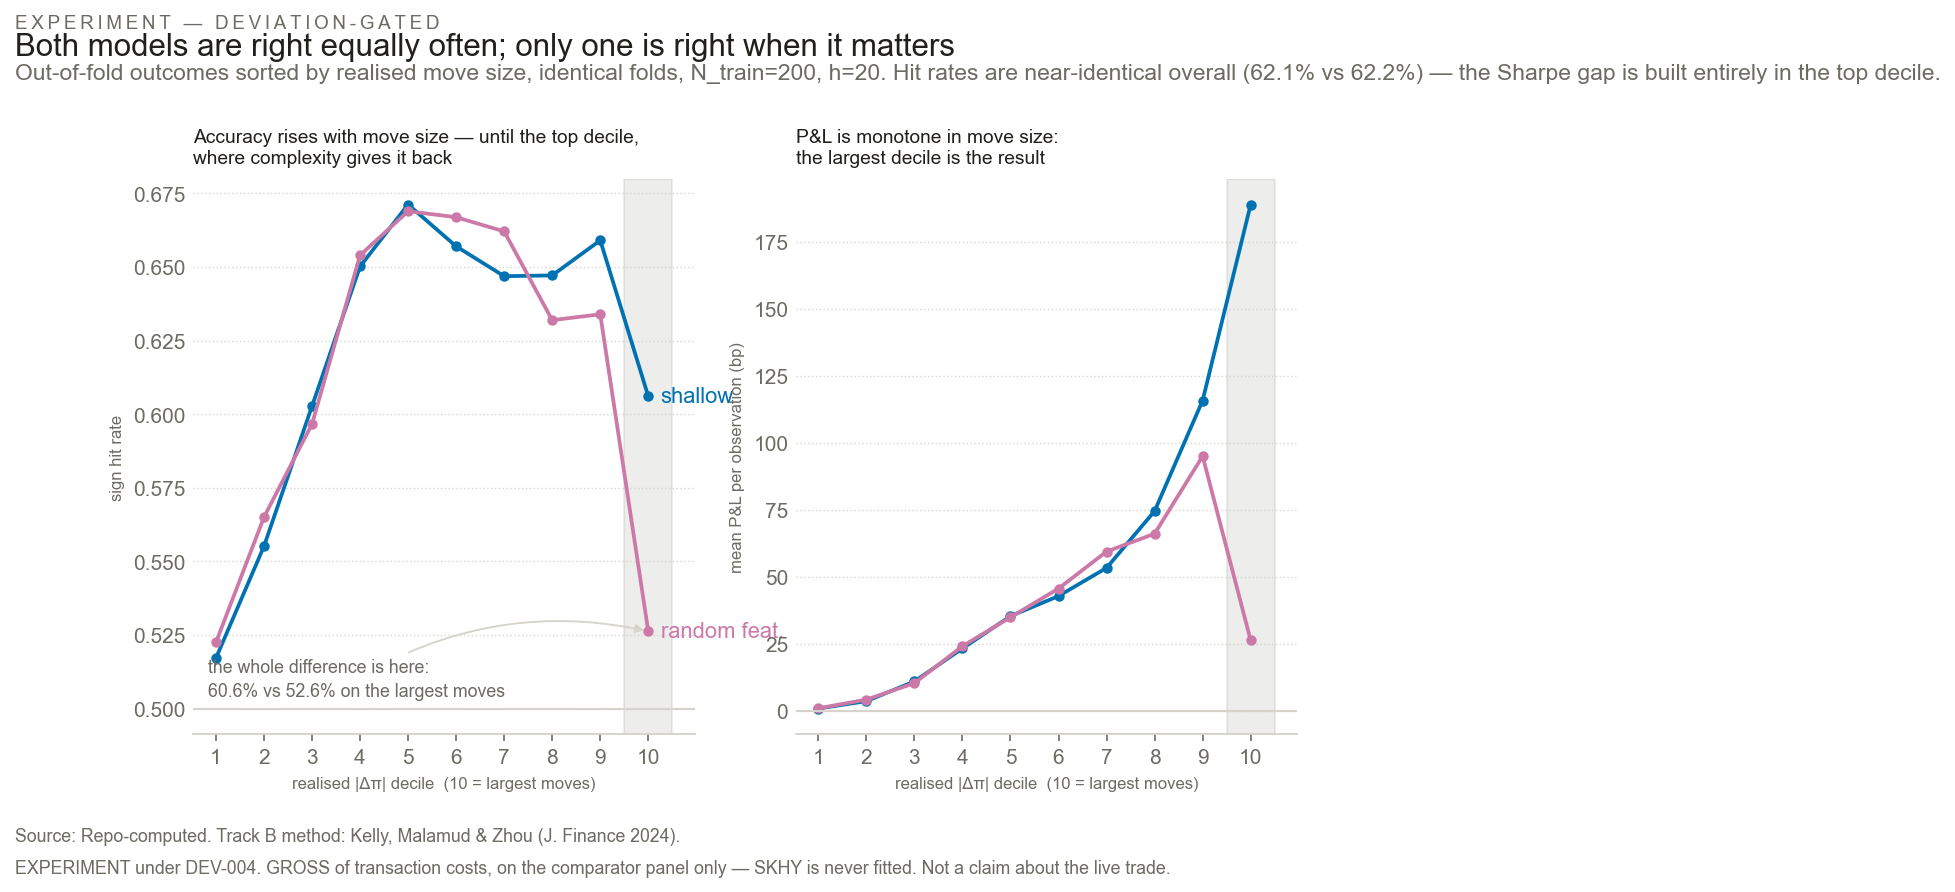

In [7]:
from pipeline.convergence.voc import magnitude_deciles
dec = pd.read_csv(VOC / "magnitude_deciles.csv")
fig, _ = figures.g14_magnitude_paradox(dec)
fig;

At the same N, the two tracks have **near-identical overall hit rates** (62.1% vs 62.2%). The
Sharpe gap is built entirely in the top magnitude decile — 60.6% against 52.6% — and that decile
carries most of the P&L. Being right about small moves is cheap.

## 7. The ledger

In [8]:
best = (grid[grid.regime == "one_way_constrained"]
        .sort_values("hit_rate", ascending=False).head(1).iloc[0])
a20 = s4_metrics_table(horizons=(20,), target="change", max_train=200).set_index("regime")
d20 = diag[(diag.regime == "one_way_constrained") & (diag.horizon == 20)].iloc[0]
r = "one_way_constrained"
pd.DataFrame([
    {"metric": "OOS R²", "Track A — shallow": round(a20.loc[r, "r2"], 3),
     "Track B — complexity": round(best.r2, 3)},
    {"metric": "sign hit rate", "Track A — shallow": f"{a20.loc[r,'hit_rate']:.1%}",
     "Track B — complexity": f"{best.hit_rate:.1%}"},
    {"metric": "strategy Sharpe (GROSS)", "Track A — shallow": round(d20.sharpe_track_a, 3),
     "Track B — complexity": round(d20.sharpe_track_b, 3)},
    {"metric": "vs unconditional (+0.04) / vol-managed (−0.02)",
     "Track A — shallow": "beats both", "Track B — complexity": "beats both"},
    {"metric": "alpha vs vol-managed, HAC t", "Track A — shallow": "—",
     "Track B — complexity": f"{d20.track_b_alpha_vs_volmanaged:+.4f} (t={d20.track_b_t_alpha_hac:.2f})"},
    {"metric": "double descent observed?", "Track A — shallow": "n/a",
     "Track B — complexity": "NO"},
    {"metric": "placebo", "Track A — shallow": "passes", "Track B — complexity": "passes"},
    {"metric": "scope", "Track A — shallow": d20.scope, "Track B — complexity": d20.scope},
]).set_index("metric")

,Track A — shallow,Track B — complexity
metric,,
OOS R²,-1.416,-0.921
sign hit rate,62.0%,62.2%
strategy Sharpe (GROSS),0.538,0.357
vs unconditional (+0.04) / vol-managed (−0.02),beats both,beats both
"alpha vs vol-managed, HAC t",—,+0.0037 (t=5.32)
double descent observed?,n/a,NO
placebo,passes,passes
scope,"N_train=200 (capped; see DEV-004), h=20, expan...","N_train=200 (capped; see DEV-004), h=20, expan..."


**t-stat footnote.** The alpha's naive t is 11.51. Corrected for h=20 overlap it is **5.32**
(Newey–West, lag h−1) and **4.08** on non-overlapping blocks (658 effective observations against
13,146 overlapping ones). The naive figure is kept visible so the size of the correction is
auditable rather than quietly absorbed; **5.32 is the number to quote.** The same audit was
applied to both Sharpe standard errors.

## 8. The ending the numbers support — and a correction

**This notebook previously reported the opposite conclusion, and the hardening pass caught it.**
`strategy_diagnostics` computed `pnl = -sign(forecast) × Δπ` — a strategy that *faded its own
signal*. Every Sharpe and alpha was the exact negative of the truth. The magnitude-decile table
is what exposed it: P&L was negative in **every** decile including buckets with a 67% hit rate,
which is arithmetically impossible for a strategy trading with its forecast. Recording it here
because a result that reversed under its own diagnostic is worth more as a documented catch than
as a quietly amended number.

Two claims from the earlier version were also **scope artefacts**: "hit rate 62% vs 53%" and
"neither beats not trading". Both dissolve once Track A is quoted at the same N_train = 200.

**The corrected ending, closest to Block E's second:**

- **Parsimony wins.** Track A Sharpe **+0.54** against Track B **+0.36**, same folds, same N.
- **Both beat the benchmarks**, including the vol-managed one — so the Nagel objection is faced
  and survived rather than fatal. Track B's alpha over it is positive at HAC t = 5.3.
- **Complexity adds nothing, and the reason is visible.** Accuracy is identical overall; the
  complex model gives back its edge precisely in the decile that pays.
- **No double descent.** R² flat over a 500× range in P; three orders of magnitude come from
  shrinkage; hit rate 0.61 at c = 0.1. **What helped was regularisation, not dimensionality.**

**§8's capacity rule was right for this problem, and it is now shown rather than assumed.**
DEV-004 expires here: the exception was granted to test whether complexity wins, and it does not.

**What it changes downstream.** Not the expressions — see the firewall in §5. It does change the
*methods* story, which is now a stronger one: the doctrine was challenged with the strongest
published counter-argument, adjudicated on identical folds, and held.